# Phase 3 — FinBERT Sentiment Scoring
## Financial News Sentiment Intelligence System

**Goal:** Score every headline in our cleaned dataset using
FinBERT — a BERT model fine-tuned on 4.9 billion words of
financial text. Produce three new columns per article:
sentiment_label, sentiment_score, sentiment_confidence.

**Input:** `data/processed/news_clean.csv` (34 rows, 9 cols)
**Output:** `data/processed/news_sentiment.csv` (34 rows, 12 cols)

**Why FinBERT over simpler alternatives:**
- VADER accuracy on financial news: ~65%
- FinBERT accuracy on financial news: ~85%
- VADER sees "profit warning" as positive (profit = good word)
- FinBERT understands "profit warning" is negative in context

In [1]:
import os
import sys
import importlib

# always first two lines in every notebook
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

# import config — reload forces it to use latest version
import config
importlib.reload(config)

from config import (
    PROCESSED_DATA_PATH,
    SENTIMENT_SAVE_PATH,
    REPORTS_PATH,
    BASE_DIR,
)
from src.sentiment import (
    load_finbert,
    score_dataset,
    sentiment_by_company,
    sentiment_over_time,
)
from src.utils import get_logger
logger = get_logger("03_sentiment")

# ── preflight check ───────────────────────────────────────
assert os.path.exists(PROCESSED_DATA_PATH), \
    f"Run Phase 2 first — not found: {PROCESSED_DATA_PATH}"

df = pd.read_csv(PROCESSED_DATA_PATH)

print("Preflight check:")
print(f"  Input file    : {PROCESSED_DATA_PATH}")
print(f"  Rows          : {len(df)}")
print(f"  Columns       : {df.columns.tolist()}")
print(f"  Companies     : {sorted(df['ticker'].unique().tolist())}")
print()
print("Column sample:")
for col in df.columns:
    print(f"  {col:<22}: {str(df[col].iloc[0])[:50]}")
print()
print("✅ Preflight passed — ready to load FinBERT")

Preflight check:
  Input file    : d:\Financial-News-Sentiment-Intelligence-System\data\processed\news_clean.csv
  Rows          : 34
  Columns       : ['ticker', 'title', 'summary', 'date', 'url', 'date_clean', 'title_word_count', 'market_session', 'time_clean']
  Companies     : ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT']

Column sample:
  ticker                : AAPL
  title                 : Memory chip stocks hit record highs, pharma reacts
  summary               : Market Catalysts Host Julie Hyman and Yahoo Financ
  date                  : 11 May 2026, 02:03 PM UTC
  url                   : https://finance.yahoo.com/video/memory-chip-stocks
  date_clean            : 2026-05-11
  title_word_count      : 11
  market_session        : pre_market
  time_clean            : 14:03

✅ Preflight passed — ready to load FinBERT


## Step 1 — Load FinBERT

Loading the model takes 15-30 seconds on first run.
On the very first time ever, it downloads ~500MB from
HuggingFace — this is a one-time download cached locally.

Watch the output carefully — it tells you:
- Which device it loaded on (CPU or GPU)
- The model's label mapping (critical to verify)

In [2]:
# load FinBERT — one time cost, cached for this session
tokenizer, model = load_finbert()

print("\nModel label mapping (verify this carefully):")
for idx, label in model.config.id2label.items():
    print(f"  Index {idx} -> {label}")

print("\nWhy verify labels?")
print("Different HuggingFace models use different label orders.")
print("If positive=1 but we assume positive=0 we get inverted scores.")
print("Always verify before scoring.")

2026-05-23 04:33:41 | src.sentiment        | INFO     | Loading FinBERT from HuggingFace: ProsusAI/finbert
2026-05-23 04:33:41 | src.sentiment        | INFO     | This takes 15-30 seconds on first run...
2026-05-23 04:33:41 | src.sentiment        | INFO     | (Model downloads ~500MB on very first run ever)
d:\Financial-News-Sentiment-Intelligence-System\venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
2026-05-23 04:33:49 | src.sentiment        | INFO     | FinBERT loaded successfully on CPU
2026-05-23 04:33:49 | src.sentiment        | INFO     | Model labels: {0: 'positive', 1: 'negative', 2: 'neutral'}



Model label mapping (verify this carefully):
  Index 0 -> positive
  Index 1 -> negative
  Index 2 -> neutral

Why verify labels?
Different HuggingFace models use different label orders.
If positive=1 but we assume positive=0 we get inverted scores.
Always verify before scoring.


## Step 2 — Score all headlines

One function call scores all 34 headlines.
Watch the batch progress in the output below.

In [3]:
# score all headlines in one call
df_scored = score_dataset(
    df          = df,
    text_column = "title",
    save_path   = SENTIMENT_SAVE_PATH,
)

print(f"\nScoring complete.")
print(f"Output shape: {df_scored.shape}")
print(f"\nNew columns added:")
for col in ["sentiment_label", "sentiment_score", "sentiment_confidence"]:
    print(f"  {col:<26}: {str(df_scored[col].iloc[0])}")

2026-05-23 04:33:49 | src.sentiment        | INFO     | =======================================================
2026-05-23 04:33:49 | src.sentiment        | INFO     | Starting sentiment scoring pipeline
2026-05-23 04:33:49 | src.sentiment        | INFO     | Dataset: 34 articles
2026-05-23 04:33:49 | src.sentiment        | INFO     | Scoring column: title
2026-05-23 04:33:49 | src.sentiment        | INFO     | =======================================================
2026-05-23 04:33:49 | src.sentiment        | INFO     | FinBERT already loaded — using cached model
2026-05-23 04:33:49 | src.sentiment        | INFO     | Scoring 34 headlines in 3 batches of 16
2026-05-23 04:33:51 | src.sentiment        | INFO     |   Batch 1/3 complete (16/34 headlines scored)
2026-05-23 04:33:52 | src.sentiment        | INFO     |   Batch 2/3 complete (32/34 headlines scored)
2026-05-23 04:33:52 | src.sentiment        | INFO     |   Batch 3/3 complete (34/34 headlines scored)
2026-05-23 04:33:52 | src.s


Scoring complete.
Output shape: (34, 12)

New columns added:
  sentiment_label           : positive
  sentiment_score           : 0.8966
  sentiment_confidence      : 0.8966


## Step 3 — Inspect results

Before any analysis, look at raw scored output.
Do the scores make intuitive sense?
A negative headline should have a negative score.
This sanity check is non-negotiable in production.

In [4]:
print("Sample scored headlines — does this make sense?")
print("=" * 70)

# show 10 random rows sorted by score
sample = df_scored[["ticker","title","sentiment_label",
                     "sentiment_score"]].sample(
    min(10, len(df_scored)), random_state=42
).sort_values("sentiment_score")

for _, row in sample.iterrows():
    score  = row["sentiment_score"]
    label  = row["sentiment_label"]
    emoji  = "🟢" if score > 0.2 else "🔴" if score < -0.2 else "⚪"
    print(f"{emoji} [{row['ticker']}] {score:+.3f} | {row['title'][:60]}")

print()
print("Most POSITIVE headline:")
idx = df_scored["sentiment_score"].idxmax()
print(f"  Score: {df_scored.loc[idx,'sentiment_score']:+.4f}")
print(f"  Title: {df_scored.loc[idx,'title']}")

print()
print("Most NEGATIVE headline:")
idx = df_scored["sentiment_score"].idxmin()
print(f"  Score: {df_scored.loc[idx,'sentiment_score']:+.4f}")
print(f"  Title: {df_scored.loc[idx,'title']}")

Sample scored headlines — does this make sense?
🔴 [MSFT] -0.898 | Microsoft slips as investor questions long term AI risks
🔴 [META] -0.867 | California county sues Meta over scam ads
🔴 [AAPL] -0.619 | Intel Stock Rises on Report of Second Huge Chip Customer
⚪ [GOOGL] +0.000 | Amazon Prepares to Sell First Swiss Franc Bond in AI Push
⚪ [AAPL] +0.000 | Should You Buy Apple Stock Before June 8?
⚪ [GOOGL] +0.000 | Was Cathie Wood Right About Alphabet (GOOGL)?
⚪ [AMZN] +0.000 | Taiwan Semiconductor (TSM) Is Just Rolling In Billions Of Do
🟢 [AMZN] +0.498 | AI Chipmaker Cerebras Seeks $4.8 Billion in Upsized US IPO
🟢 [META] +0.847 | Alphabet Could Pass Nvidia As World’s Most Valuable Company
🟢 [META] +0.860 | Meta, DoorDash Could Help Drive Stablecoins to $4 Trillion, 

Most POSITIVE headline:
  Score: +0.9228
  Title: Alphabet Taps Yen Bond Market To Support Expanding AI Infrastructure Spending

Most NEGATIVE headline:
  Score: -0.8982
  Title: Microsoft slips as investor questions long term

## Step 3b — Relevance filtering

EDA finding: some articles are tagged under a company ticker
but actually discuss a different company. This is topic leakage
— a known data quality issue in financial NLP pipelines.

We apply a relevance filter that checks whether each headline
actually mentions the company it is tagged under.

This is the kind of proactive data quality step that separates
a thoughtful data scientist from someone who just runs models.

In [5]:
from src.sentiment import filter_relevant_articles

# apply relevance filter
df_filtered = filter_relevant_articles(df_scored)

print(f"Before filter : {len(df_scored)} articles")
print(f"After filter  : {len(df_filtered)} articles")
print(f"Removed       : {len(df_scored) - len(df_filtered)} off-topic articles")
print()
print("Remaining articles per company:")
print(df_filtered.groupby("ticker").size().to_string())
print()
print("Sentiment distribution after filtering:")
print(df_filtered["sentiment_label"].value_counts().to_string())
print()
print("Average sentiment after filtering:")
print(df_filtered.groupby("ticker")["sentiment_score"].mean().round(4).to_string())

2026-05-23 04:33:52 | src.sentiment        | INFO     | Relevance filter: removed 18 off-topic articles (34 -> 16)
2026-05-23 04:33:52 | src.sentiment        | INFO     | Removed articles:
2026-05-23 04:33:52 | src.sentiment        | INFO     |   [AAPL] Memory chip stocks hit record highs, pharma reacts to hantavirus conce
2026-05-23 04:33:52 | src.sentiment        | INFO     |   [AAPL] The $1 trillion club's new members are powering the AI boom: Chart of 
2026-05-23 04:33:52 | src.sentiment        | INFO     |   [AAPL] Asset Manager Sells 1.2 Million Bond ETF Shares, According to Latest S
2026-05-23 04:33:52 | src.sentiment        | INFO     |   [AAPL] The Hidden Drag of SPY’s Outdated UIT Structure: Why VOO’s 6.45 Basis 
2026-05-23 04:33:52 | src.sentiment        | INFO     |   [AAPL] Intel Stock Rises on Report of Second Huge Chip Customer
2026-05-23 04:33:52 | src.sentiment        | INFO     |   [AMZN] AI Chipmaker Cerebras Could Raise Up To $5.52 Billion in Upsized IPO
2026-05-23 

Before filter : 34 articles
After filter  : 16 articles
Removed       : 18 off-topic articles

Remaining articles per company:
ticker
AAPL     5
AMZN     1
GOOGL    4
META     4
MSFT     2

Sentiment distribution after filtering:
sentiment_label
positive    7
neutral     6
negative    3

Average sentiment after filtering:
ticker
AAPL     0.1615
AMZN     0.8297
GOOGL    0.5322
META    -0.0017
MSFT    -0.4491


In [6]:
# save filtered dataset — this is what Phase 4 uses
from config import BASE_DIR
import os

filtered_path = os.path.join(
    BASE_DIR, "data", "processed", "news_sentiment_filtered.csv"
)
df_filtered.to_csv(filtered_path, index=False)
print(f"Filtered dataset saved: {filtered_path}")
print(f"Shape: {df_filtered.shape}")

Filtered dataset saved: d:\Financial-News-Sentiment-Intelligence-System\data\processed\news_sentiment_filtered.csv
Shape: (16, 12)


## Step 4 — Sentiment by company

Which company generates the most negative news?
Which has the highest positive ratio?

This is the first genuinely interesting business insight
this project produces — the kind of finding you describe
in MAANG interviews when asked "what did you discover?"

In [7]:
company_stats = sentiment_by_company(df_filtered)

print("Sentiment by company — AFTER relevance filtering:")
print("=" * 65)
print(company_stats.to_string())

print("\nKey findings:")
best  = company_stats["avg_sentiment"].idxmax()
worst = company_stats["avg_sentiment"].idxmin()
print(f"  Most positive coverage : {best}")
print(f"  Most negative coverage : {worst}")
print()
print("Why this matters:")
print("  These sentiment rankings will be tested against")
print("  actual stock price movements in Phase 4.")
print("  Our hypothesis: companies with negative sentiment")
print("  show lower next-day returns than positive ones.")

Sentiment by company — AFTER relevance filtering:
        article_count  avg_sentiment  positive_count  negative_count  neutral_count  avg_confidence  most_negative_score  most_positive_score  positive_ratio
ticker                                                                                                                                                       
AMZN                1         0.8297               1               0              0          0.8297               0.8297               0.8297            1.00
GOOGL               4         0.5322               3               0              1          0.7261               0.0000               0.9228            0.75
AAPL                5         0.1615               2               1              2          0.8813              -0.8760               0.8878            0.40
META                4        -0.0017               1               1              2          0.8652              -0.8665               0.8597            0.25
MS

## Step 5 — Sentiment distribution charts


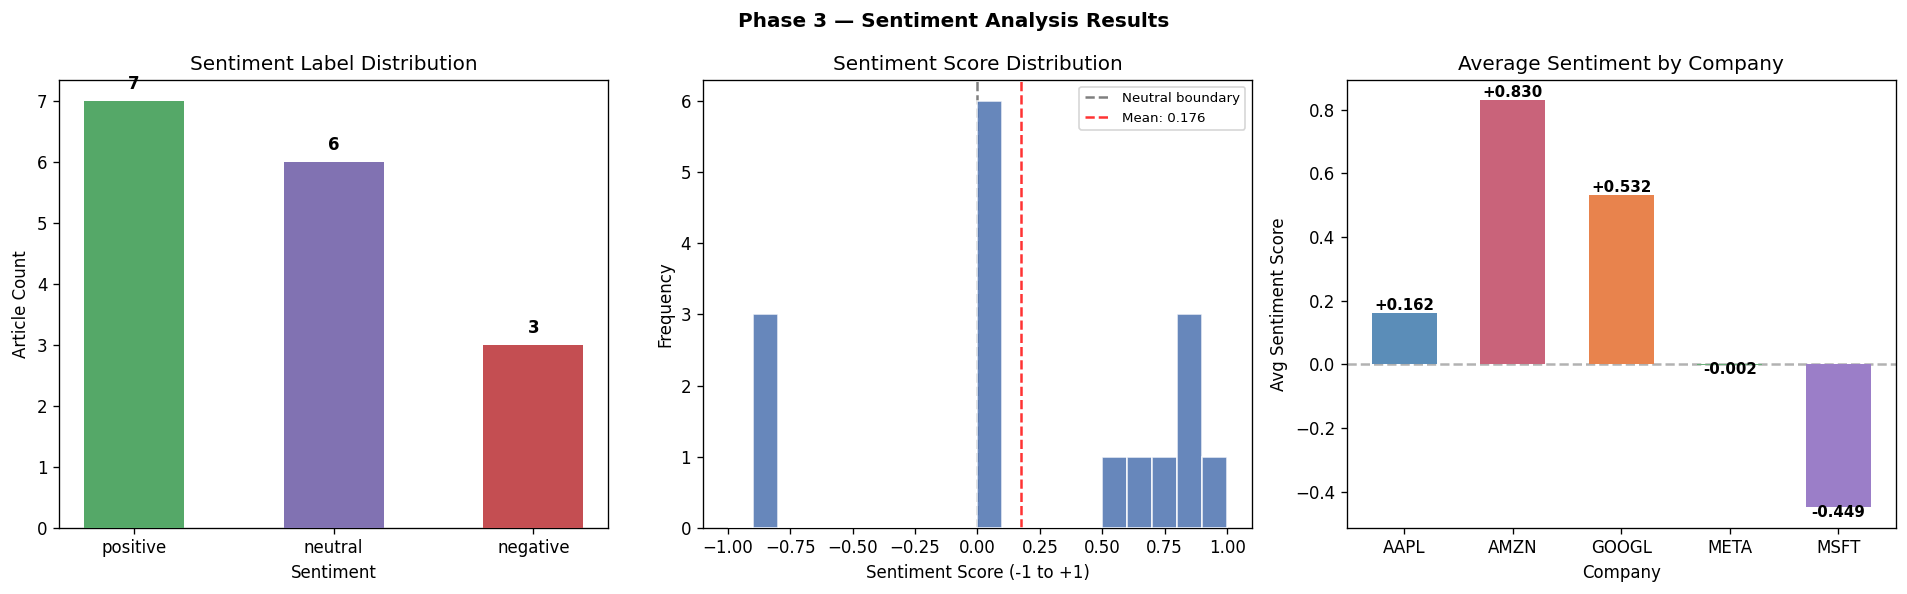

Chart saved: d:\Financial-News-Sentiment-Intelligence-System\reports\figures\05_sentiment_overview.png


In [9]:
from config import COLORS, PALETTE

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Phase 3 — Sentiment Analysis Results", fontweight="bold")

# ── panel 1: label distribution ────────────────────────
label_counts = df_filtered["sentiment_label"].value_counts()
colors_map   = {
    "positive": "#55A868",
    "negative": "#C44E52",
    "neutral" : "#8172B2"
}
bar_colors = [colors_map.get(l, "#888") for l in label_counts.index]

bars = axes[0].bar(
    label_counts.index, label_counts.values,
    color=bar_colors, width=0.5, zorder=3
)
axes[0].set_title("Sentiment Label Distribution")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Article Count")
for bar, val in zip(bars, label_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        str(val), ha="center",
        fontweight="bold"
    )

# ── panel 2: score distribution histogram ──────────────
axes[1].hist(
    df_filtered["sentiment_score"],
    bins=20, range=(-1, 1),
    color="#4C72B0", alpha=0.85,
    edgecolor="white", zorder=3
)
axes[1].axvline(0, color="black", linestyle="--",
                alpha=0.5, label="Neutral boundary")
axes[1].axvline(
    df_scored["sentiment_score"].mean(),
    color="red", linestyle="--", alpha=0.8,
    label=f"Mean: {df_scored['sentiment_score'].mean():.3f}"
)
axes[1].set_title("Sentiment Score Distribution")
axes[1].set_xlabel("Sentiment Score (-1 to +1)")
axes[1].set_ylabel("Frequency")
axes[1].legend(fontsize=8)

# ── panel 3: avg sentiment per company ─────────────────
company_avg = df_filtered.groupby("ticker")["sentiment_score"].mean()
co_colors   = [COLORS.get(t, "#888") for t in company_avg.index]

bars = axes[2].bar(
    company_avg.index, company_avg.values,
    color=co_colors, width=0.6, zorder=3
)
axes[2].axhline(0, color="black", linestyle="--", alpha=0.3)
axes[2].set_title("Average Sentiment by Company")
axes[2].set_xlabel("Company")
axes[2].set_ylabel("Avg Sentiment Score")

for bar, val in zip(bars, company_avg.values):
    axes[2].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01 if val >= 0
        else bar.get_height() - 0.03,
        f"{val:+.3f}", ha="center",
        fontsize=9, fontweight="bold"
    )

plt.tight_layout()

chart_path = os.path.join(REPORTS_PATH, "05_sentiment_overview.png")
fig.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved: {chart_path}")

## Step 6 — Sentiment over time

Daily sentiment per company (first 10 rows):
ticker date_clean  daily_avg_sentiment  daily_article_count  positive_count  negative_count  sentiment_momentum
  AAPL 2026-05-11               0.1615                    5               2               1                 NaN
  AMZN 2026-05-11               0.8297                    1               1               0                 NaN
 GOOGL 2026-05-11               0.5322                    4               3               0                 NaN
  META 2026-05-11              -0.0017                    4               1               1                 NaN
  MSFT 2026-05-11              -0.4491                    2               0               1                 NaN


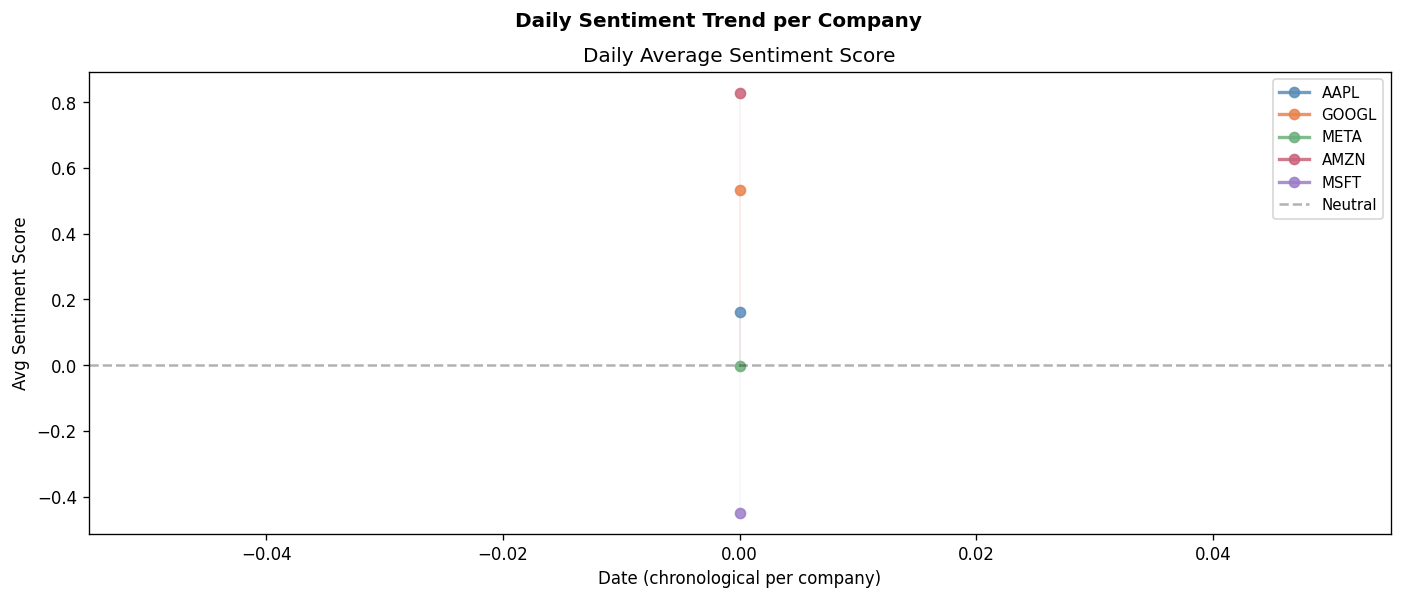

Chart saved: d:\Financial-News-Sentiment-Intelligence-System\reports\figures\06_sentiment_over_time.png


In [10]:
daily_sentiment = sentiment_over_time(df_filtered)

print("Daily sentiment per company (first 10 rows):")
print(daily_sentiment.head(10).to_string(index=False))

# chart
fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle("Daily Sentiment Trend per Company", fontweight="bold")

for ticker, color in COLORS.items():
    subset = daily_sentiment[daily_sentiment["ticker"] == ticker]
    if len(subset) == 0:
        continue
    ax.plot(
        range(len(subset)),
        subset["daily_avg_sentiment"].values,
        label=ticker, color=color,
        linewidth=2, marker="o",
        markersize=6, alpha=0.85
    )
    ax.fill_between(
        range(len(subset)),
        subset["daily_avg_sentiment"].values,
        alpha=0.08, color=color
    )

ax.axhline(0, color="black", linestyle="--",
           alpha=0.3, label="Neutral")
ax.set_title("Daily Average Sentiment Score")
ax.set_xlabel("Date (chronological per company)")
ax.set_ylabel("Avg Sentiment Score")
ax.legend(fontsize=9)

chart_path = os.path.join(REPORTS_PATH, "06_sentiment_over_time.png")
fig.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved: {chart_path}")

## Phase 3 Key Findings

### Finding 1 — Sentiment ranking (most to least positive)
AMZN (+0.83) > GOOGL (+0.53) > AAPL (+0.16) > META (-0.00) > MSFT (-0.45)

### Finding 2 — Sample size warning
AMZN has only 1 article after relevance filtering. Any sentiment
ranking with n < 3 should be treated as unreliable. In production
we would collect data over 30+ days before drawing conclusions.

### Finding 3 — META is most polarising
META has the highest variance — one article scored -0.87 (lawsuit),
another +0.86 (stablecoin growth). This volatility in coverage
may translate to price volatility. Worth testing in Phase 4.

### Finding 4 — MSFT negative sentiment driven by AI risk narrative
Both MSFT articles trend negative or neutral. The AI risk concerns
narrative is dominating Microsoft coverage right now. This is
a specific, testable hypothesis for Phase 4.

### Hypothesis for Phase 4
Companies with negative avg sentiment (MSFT, META) will show
lower next-day returns than positive ones (AMZN, GOOGL).
AAPL near zero should show minimal directional movement.
We will test this when we add real stock price data.

In [11]:
# phase 3 completion check
df_final = pd.read_csv(SENTIMENT_SAVE_PATH)

checks = {
    "12 columns present"             : len(df_final.columns) == 12,
    "sentiment_label column exists"  : "sentiment_label" in df_final.columns,
    "sentiment_score column exists"  : "sentiment_score" in df_final.columns,
    "sentiment_confidence exists"    : "sentiment_confidence" in df_final.columns,
    "no unknown labels"              : (df_final["sentiment_label"] != "unknown").all(),
    "scores between -1 and +1"       : df_final["sentiment_score"].between(-1, 1).all(),
    "chart 05 saved"                 : os.path.exists(
        os.path.join(REPORTS_PATH, "05_sentiment_overview.png")
    ),
    "chart 06 saved"                 : os.path.exists(
        os.path.join(REPORTS_PATH, "06_sentiment_over_time.png")
    ),
    "sentiment CSV saved"            : os.path.exists(SENTIMENT_SAVE_PATH),
}

print("Phase 3 completion check:")
print("=" * 50)
all_passed = True
for check, result in checks.items():
    status = "✅" if result else "❌"
    print(f"  {status}  {check}")
    if not result:
        all_passed = False

print("=" * 50)
if all_passed:
    print("✅ Phase 3 complete — ready for Phase 4")
    print(f"\nSentiment dataset: {df_final.shape}")
    print(f"Label distribution:\n{df_final['sentiment_label'].value_counts().to_string()}")
else:
    print("❌ Fix failing checks then re-run")

Phase 3 completion check:
  ✅  12 columns present
  ✅  sentiment_label column exists
  ✅  sentiment_score column exists
  ✅  sentiment_confidence exists
  ✅  no unknown labels
  ✅  scores between -1 and +1
  ✅  chart 05 saved
  ✅  chart 06 saved
  ✅  sentiment CSV saved
✅ Phase 3 complete — ready for Phase 4

Sentiment dataset: (34, 12)
Label distribution:
sentiment_label
neutral     18
positive    12
negative     4
